#### Visualization demo of `pinn_pat_forward_example.ckpt`

- Checkpoint is generated by `../run/run_vessel_forward.py`
- The PINN model is optimized with constraints of initial pressure $p_0$, wave equation and initial condition ($\partial p / \partial t|_{t=0}=0$)

------

In [ ]:
import torch
torch.set_grad_enabled(False)
import sys
from matplotlib import pyplot as plt
import json
from pprint import pprint
sys.path.append("..")


from models.pinn_for_pat import PINNForPAT
from models.arg import Arg
device = torch.device("cpu")


In [4]:
ckpt_filepath = "../ckpt/forward/pinn_pat_forward_example.ckpt"
state_dict = torch.load(ckpt_filepath, map_location=torch.device('cpu'))

arg_dict = json.loads(bytes(state_dict['arg'].numpy()).decode('utf-8'))
pprint(arg_dict)

arg = Arg.from_dict(arg_dict)
arg.load_filepath = ckpt_filepath
pinn_pat = PINNForPAT(arg, device=device)

{'activation': 'Sin',
 'bc_batch_size': None,
 'dpdt0_weight': 1e-06,
 'fit_type': 'Forward',
 'in_channels': 3,
 'l_layers': 9,
 'load_filepath': None,
 'lr_end': 1e-05,
 'lr_start': 0.0002,
 'medium': 'A: Homogeneous and unlossy',
 'n_hidden': 180,
 'n_t': 700,
 'num_iteration': 500000,
 'out_channels': 1,
 'p0_batch_size': None,
 'p0_filepath': '../phantom/vessel/p0_vessel_r8_mask.pts',
 'pde_batch_size': 10000,
 'pde_weight': 1e-07,
 'save_filepath': '../ckpt/pinn_pat_gs_0917_1326.ckpt',
 'sensor_filepath': None,
 't0_batch_size': 5000,
 't_max': 1.05,
 't_min': 0.0}
Load: ../ckpt/forward/pinn_pat_forward_example.ckpt <All keys matched successfully>
 [PINNForPAT]  {'medium': 'A: Homogeneous and unlossy', 'fit_type': 'Forward', 'in_channels': 3, 'out_channels': 1, 'n_hidden': 180, 'l_layers': 9, 'activation': 'Sin', 't_min': 0.0, 't_max': 1.05, 'n_t': 700, 'pde_batch_size': 10000, 't0_batch_size': 5000, 'bc_batch_size': None, 'p0_batch_size': None, 'pde_weight': 1e-07, 'dpdt0_weight

### Pressure field evolution (0~0.18 $\rm{\mu s}$ )

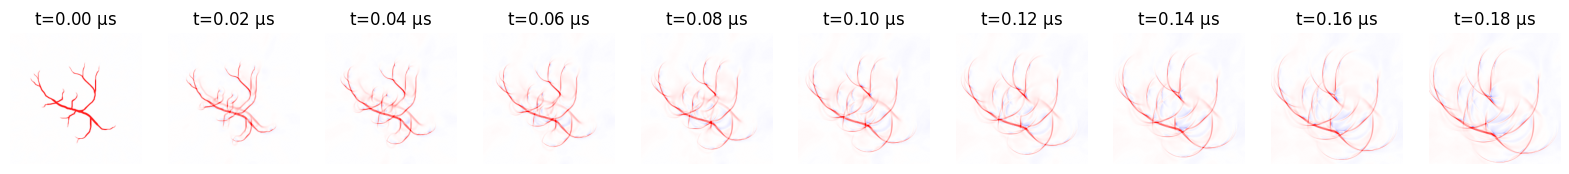

In [ ]:

H = 256
X_axis = torch.linspace(0, 1, 2 * H + 1)[1::2]
x, y = torch.meshgrid([X_axis] * 2, indexing="ij")


fig, axes = plt.subplots(dpi=100, figsize=(20, 2), ncols=10)
list(map(lambda ax:ax.axis(False), axes.flatten()))
for it, t in enumerate(torch.arange(10) * 0.02):
    p0 = pinn_pat.p(torch.stack([x, y, torch.zeros_like(x) + t], dim=-1))
    if it == 0:
        vmax = max(p0.max(), 1e-5)
    axes[it].imshow(p0, cmap="bwr", vmax=vmax, vmin=-vmax)
    axes[it].set_title(f"t={t:.2f}" + r" $\rm{\mu s}$")
    